In [50]:
# Ensure all figures save under analysis/images
from pathlib import Path
import matplotlib.pyplot as plt

# Image directory relative to notebook location (analysis/images)
IMG_DIR = Path("images")
IMG_DIR.mkdir(parents=True, exist_ok=True)

_original_savefig = plt.savefig

def _savefig_into_images(*args, **kwargs):
    """Wrap plt.savefig so relative filenames land in analysis/images.

    - Absolute paths are left unchanged.
    - Names that already start with "images/" stay under that directory
      (we avoid nesting images/images/...).
    """
    if args:
        fname = args[0]
        p = Path(fname)
        if not p.is_absolute():
            # If user already passed images/foo.png, keep that path; otherwise
            # drop any directory components and write to images/<name>.
            if p.parts and p.parts[0] == "images":
                target = p
            else:
                target = IMG_DIR / p.name
            args = (str(target), *args[1:])
    return _original_savefig(*args, **kwargs)

plt.savefig = _savefig_into_images

# Filestore Tiering — Policy Benchmark Analysis

Grouped bar charts across all presets and policy variants.
Each chart shows one metric; within each preset band the 15 policy bars are colored by policy family.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

# ── Load ───────────────────────────────────────────────────────────────────────
CSV_PATH = Path('../bench_results.csv')
IMG_DIR = Path('graphs')
IMG_DIR.mkdir(exist_ok=True)

df = pd.read_csv(CSV_PATH)

print(f'Loaded {len(df)} rows from {CSV_PATH}')
print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '../big_daddy_results.csv.csv'

In [57]:
# ── Derived columns ────────────────────────────────────────────────────────────
# Raw metrics
df['hit_pct']        = df['hit_rate'] * 100

# Per-preset medians
median_hit_by_preset   = df.groupby('preset')['hit_pct'].transform('median')
median_promos_by_preset = df.groupby('preset')['promotions'].transform('median')

# Deviations in absolute terms (percentage points for hit rate)
df['hit_delta_pct']     = df['hit_pct'] - median_hit_by_preset

# Relative deviations (% of preset median), so each preset band is normalized
# to its own scale. E.g. +20 means "20% above that preset's median".
df['hit_rel_pct']       = (df['hit_pct'] / median_hit_by_preset - 1.0) * 100.0
df['promotions_rel_pct'] = (df['promotions'] / median_promos_by_preset - 1.0) * 100.0

# Byte/compute metrics
df['hot_KB']         = df['bytes_wr_hot']   / 1024
df['cold_KB']        = df['bytes_wr_cold0'] / 1024
df['total_moves_KB'] = df['hot_KB'] + df['cold_KB']
df['reorg_ms']       = df['reorganize_us'] / 1_000
df['ingest_ms']      = df['ingest_us']     / 1_000

# ── Canonical ordering ─────────────────────────────────────────────────────────
PRESETS = ['steady_state', 'frequency_favored', 'recency_favored', 'high_churn', 'hot_set']
PRESET_LABELS = {
    'steady_state':      'Steady\nState',
    'frequency_favored': 'Freq\nFavored',
    'recency_favored':   'Recency\nFavored',
    'high_churn':        'High\nChurn',
    'hot_set':           'Hot\nSet',
}

POLICIES = [
    'basic_lru',
    'arc',
    'lfu',
    'lru_2q',          'lru_2q_small',      'lru_2q_large',
    'lecar',           'lecar_fast',         'lecar_slow',
    'cacheus',         'cacheus_lru_biased', 'cacheus_lfu_biased',
    'decision_tree',   'decision_tree_deep', 'decision_tree_fast',
]

# Policy-family color palette
POLICY_COLORS = {
    'basic_lru':           '#4C72B0',
    'arc':                 '#55A868',
    'lfu':                 '#C44E52',
    # lru-2q family — purples
    'lru_2q':              '#8172B2',
    'lru_2q_small':        '#A89CCC',
    'lru_2q_large':        '#5C4B9B',
    # lecar family — oranges
    'lecar':               '#E07B39',
    'lecar_fast':          '#F5A623',
    'lecar_slow':          '#A0522D',
    # cacheus family — teals
    'cacheus':             '#17BECF',
    'cacheus_lru_biased':  '#2ECC71',
    'cacheus_lfu_biased':  '#0E7F8A',
    # decision-tree family — reds
    'decision_tree':       '#E74C3C',
    'decision_tree_deep':  '#922B21',
    'decision_tree_fast':  '#FF8C94',
}

# Filter to only rows whose policy/preset we expect
df = df[df['preset'].isin(PRESETS) & df['policy'].isin(POLICIES)]

print(f'After filter: {len(df)} rows  |  presets: {df["preset"].nunique()}  |  policies: {df["policy"].nunique()}')

After filter: 75 rows  |  presets: 5  |  policies: 15


In [58]:
# ── Shared plotting helper ─────────────────────────────────────────────────────

def grouped_bar(ax, metric, ylabel, title=None, fmt='{:.1f}', scale=1.0, annotate=False):
    """Draw a grouped bar chart: preset bands on x-axis, one bar per policy."""
    n_presets  = len(PRESETS)
    n_policies = len(POLICIES)
    group_width = 0.85
    bar_w = group_width / n_policies

    # Aggregate: mean over runs if RUNS > 1
    agg = df.groupby(['preset', 'policy'])[metric].mean() * scale

    xs = np.arange(n_presets, dtype=float)

    for i, policy in enumerate(POLICIES):
        offset = (i - n_policies / 2 + 0.5) * bar_w
        vals = [agg.get((p, policy), 0.0) for p in PRESETS]
        bars = ax.bar(
            xs + offset, vals, width=bar_w * 0.95,
            color=POLICY_COLORS[policy], alpha=0.88,
            edgecolor='white', linewidth=0.4, label=policy,
        )
        if annotate:
            for bar, v in zip(bars, vals):
                if v > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                            fmt.format(v), ha='center', va='bottom',
                            fontsize=5, rotation=90)

    ax.set_xticks(xs)
    ax.set_xticklabels([PRESET_LABELS[p] for p in PRESETS], fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    if title:
        ax.set_title(title, fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(-0.5, n_presets - 0.5)


def policy_legend(fig, ncol=5):
    """Attach a compact legend for all policy colors to the figure."""
    handles = [
        mpatches.Patch(color=POLICY_COLORS[p], label=p)
        for p in POLICIES
    ]
    fig.legend(
        handles=handles, loc='lower center',
        ncol=ncol, fontsize=8.5,
        frameon=True, framealpha=0.9,
        bbox_to_anchor=(0.5, -0.01),
    )

print('Helpers defined.')

Helpers defined.


## Chart 1 — Hit Rate (%)

**Higher is better.** Fraction of edit operations that landed on a hot (non-symlink) file.
This is the primary quality metric for tiering policy placement.

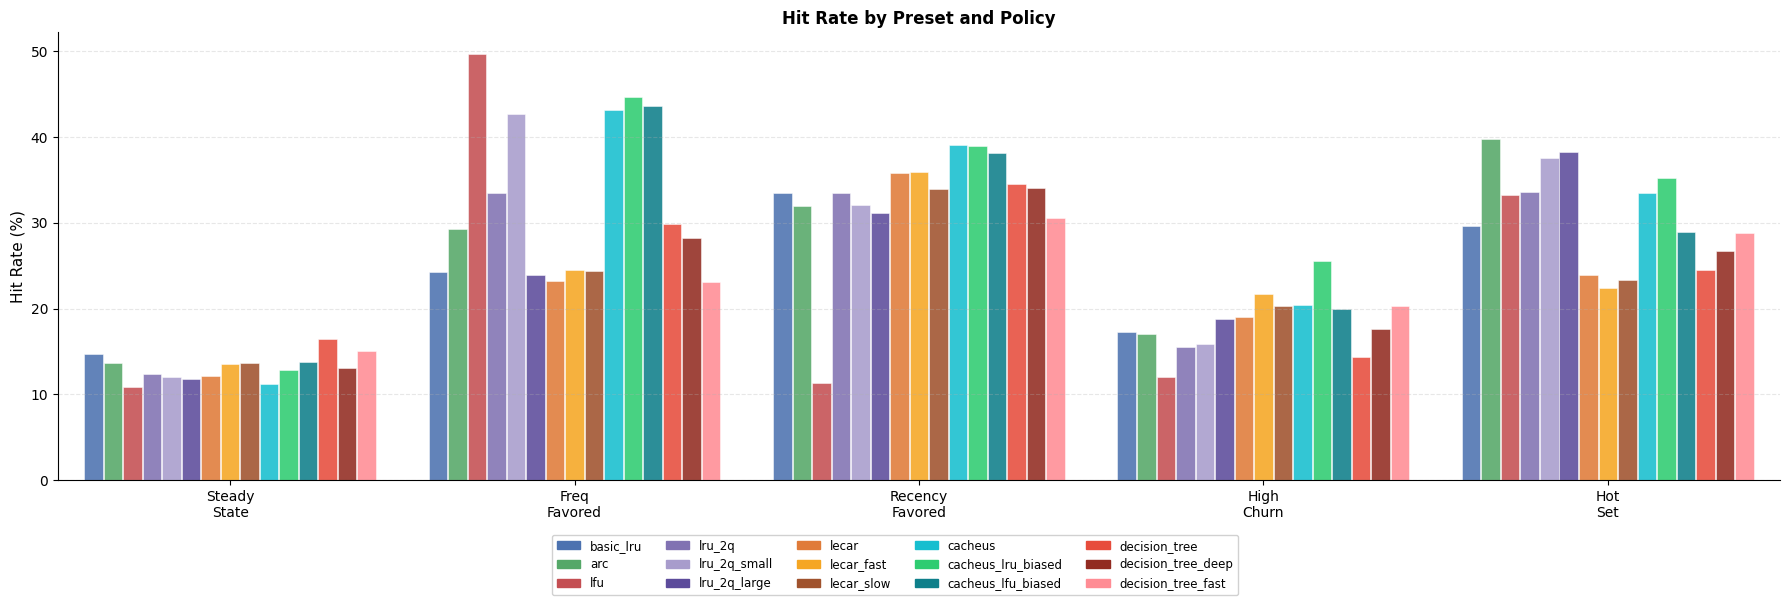

In [59]:
fig, ax = plt.subplots(figsize=(18, 6))
grouped_bar(ax, 'hit_pct', 'Hit Rate (%)', title='Hit Rate by Preset and Policy')
policy_legend(fig)
fig.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig('hit_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 1 — Hit Rate Δ vs. Preset Median (pp)

Instead of raw hit rate, this chart shows **deviation from the per-preset median**.
For each preset we compute the median hit rate across all policies, and plot
`policy_hit_rate - preset_median` in percentage points. This makes relative
policy differences pop even when all policies sit in the same absolute band.

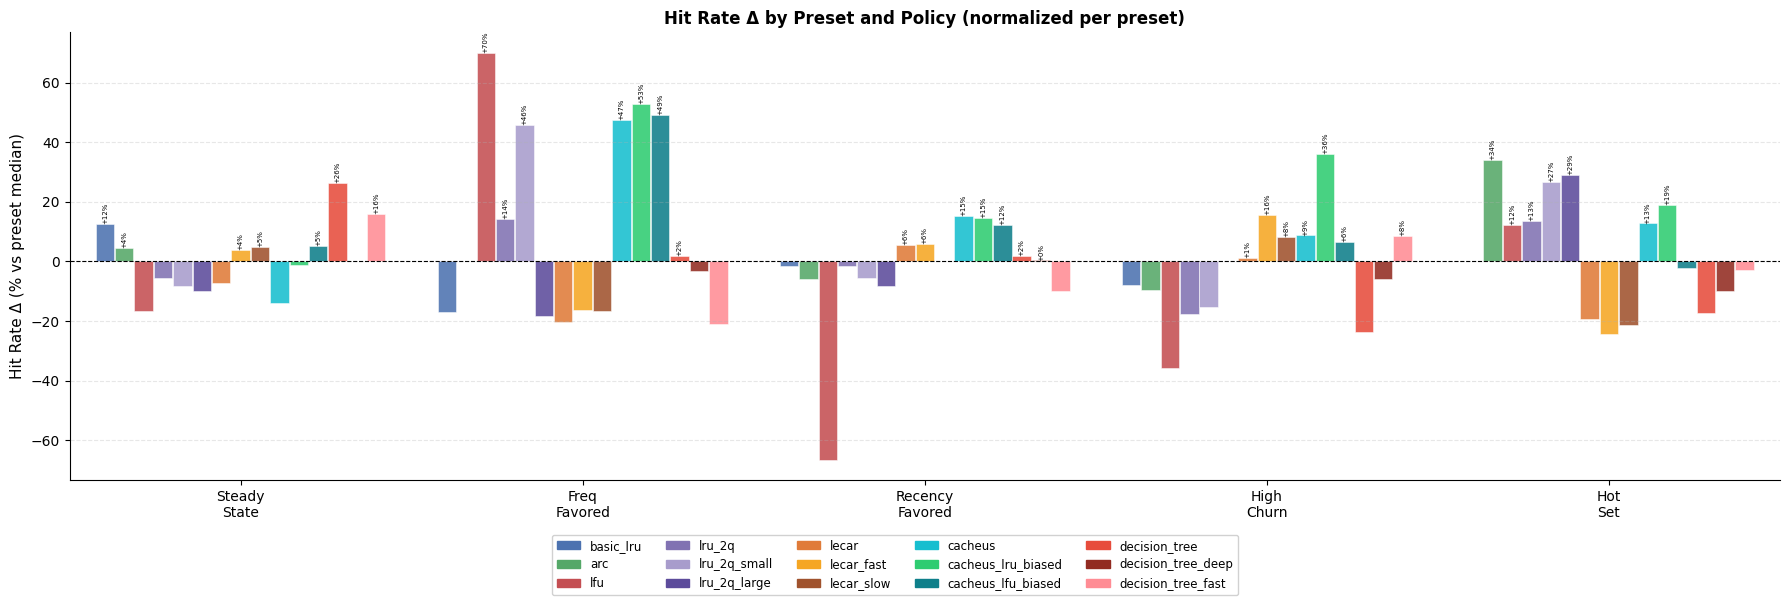

In [60]:
fig, ax = plt.subplots(figsize=(18, 6))

# Plot deviation **relative to each preset's own median** hit rate, so that
# each band is normalized to its own scale instead of sharing an absolute
# y-axis. Values are in percentage-of-median (e.g. +25 = 25% above median).
grouped_bar(
    ax,
    'hit_rel_pct',
    'Hit Rate Δ (% vs preset median)',
    title='Hit Rate Δ by Preset and Policy (normalized per preset)',
    fmt='{:+.0f}%',
    scale=1.0,
    annotate=True,
)

# Zero-line for reference
ax.axhline(0.0, color='black', linewidth=0.8, linestyle='--')

policy_legend(fig)
fig.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig('images/hit_rate_delta.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 2 — Daemon Move Throughput (Promotions & Demotions)

**Lower is better** for a given hit rate — excess churn means the policy is thrashing.
Stacked bars show promotions (hot writes) and demotions (cold writes) per preset.

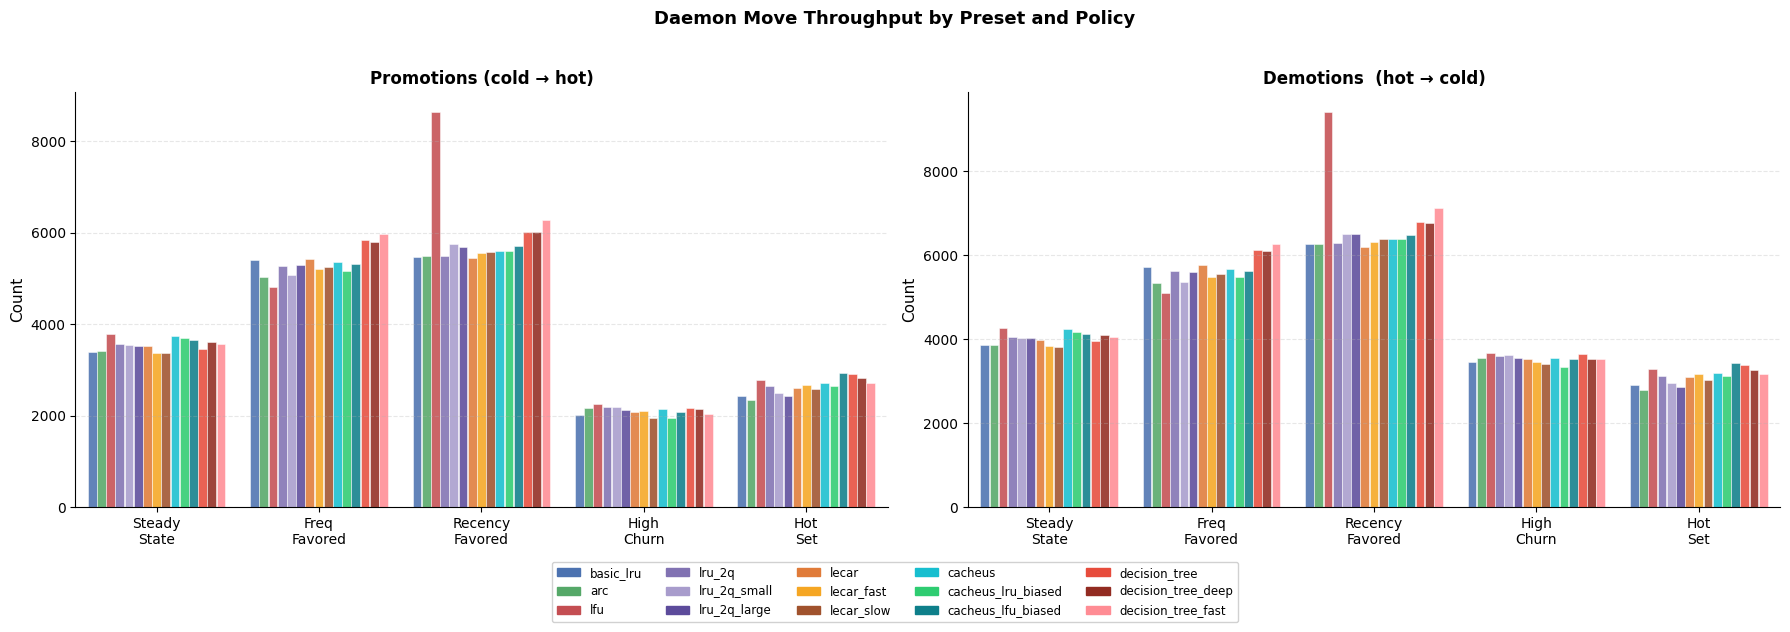

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)
grouped_bar(axes[0], 'promotions', 'Count', title='Promotions (cold → hot)')
grouped_bar(axes[1], 'demotions',  'Count', title='Demotions  (hot → cold)')
policy_legend(fig)
fig.suptitle('Daemon Move Throughput by Preset and Policy', fontweight='bold', fontsize=13, y=1.02)
fig.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig('move_throughput.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 3 — Bytes Written to Each Tier (KB)

**Economic I/O cost.** In a cloud deployment (NVMe hot / S3 cold), every byte written
to cold storage is a PUT request charge. Lower cold KB = cheaper policy execution.
Promotions (hot KB) reflect bandwidth cost of pulling data back from cold.

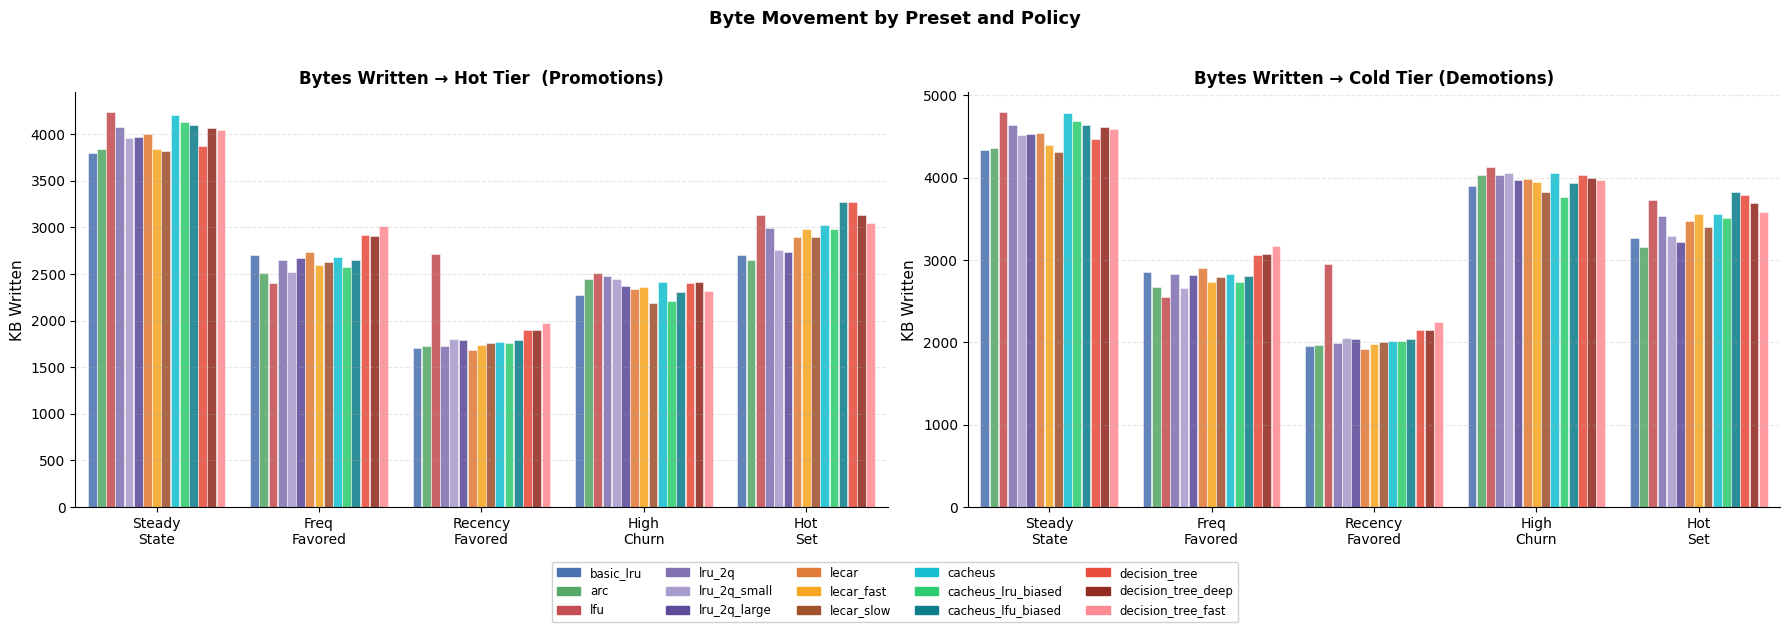

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)
grouped_bar(axes[0], 'hot_KB',  'KB Written', title='Bytes Written → Hot Tier  (Promotions)')
grouped_bar(axes[1], 'cold_KB', 'KB Written', title='Bytes Written → Cold Tier (Demotions)')
policy_legend(fig)
fig.suptitle('Byte Movement by Preset and Policy', fontweight='bold', fontsize=13, y=1.02)
fig.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig('byte_movement.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 4 — Hit Rate vs. Demotion KB (Efficiency Scatter)

**Upper-left is ideal:** high hit rate, low cold-write cost.
Each point is one (preset, policy) pair. Policies that achieve high hit rate without
excessive demotions are the most cost-efficient.

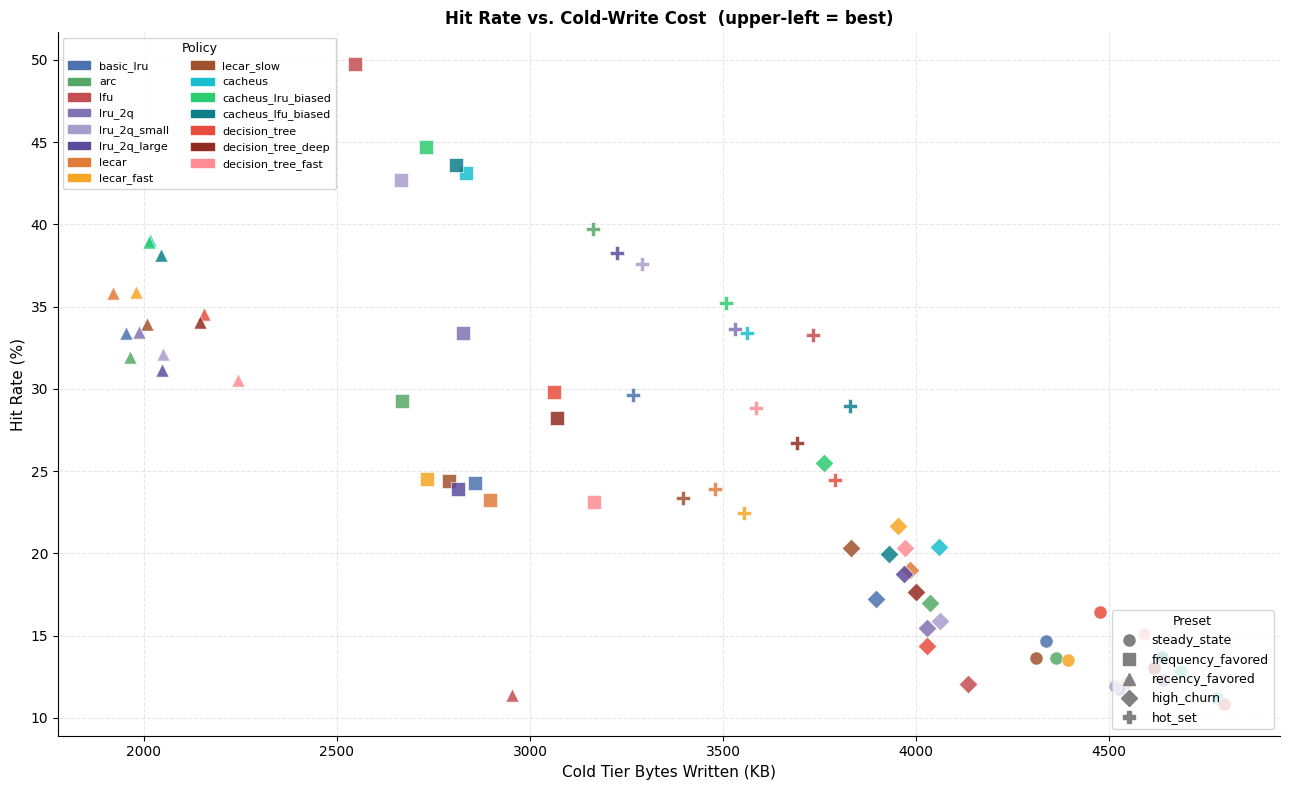

In [47]:
agg = df.groupby(['policy', 'preset'])[['hit_pct', 'cold_KB', 'hot_KB']].mean().reset_index()

PRESET_MARKERS = {
    'steady_state':      'o',
    'frequency_favored': 's',
    'recency_favored':   '^',
    'high_churn':        'D',
    'hot_set':           'P',
}

fig, ax = plt.subplots(figsize=(13, 8))

for _, row in agg.iterrows():
    ax.scatter(
        row['cold_KB'], row['hit_pct'],
        color=POLICY_COLORS[row['policy']],
        marker=PRESET_MARKERS[row['preset']],
        s=90, alpha=0.85, edgecolors='white', linewidths=0.5,
        zorder=3,
    )

# Legend: policy colors
policy_handles = [
    mpatches.Patch(color=POLICY_COLORS[p], label=p) for p in POLICIES
]
preset_handles = [
    plt.Line2D([0], [0], marker=m, color='gray', linestyle='None',
               markersize=8, label=p)
    for p, m in PRESET_MARKERS.items()
]

l1 = ax.legend(handles=policy_handles, loc='upper left',
               fontsize=8, title='Policy', title_fontsize=9, ncol=2)
ax.legend(handles=preset_handles, loc='lower right',
          fontsize=9, title='Preset', title_fontsize=9)
ax.add_artist(l1)

ax.set_xlabel('Cold Tier Bytes Written (KB)', fontsize=11)
ax.set_ylabel('Hit Rate (%)', fontsize=11)
ax.set_title('Hit Rate vs. Cold-Write Cost  (upper-left = best)', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('efficiency_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 5 — Daemon Compute Time (reorganize_ms)

Total time the daemon spent in `reorganize()` during the measurement window.
In production this runs asynchronously (invisible to clients), but high compute
time here indicates algorithmic complexity — relevant when scaling to many files.

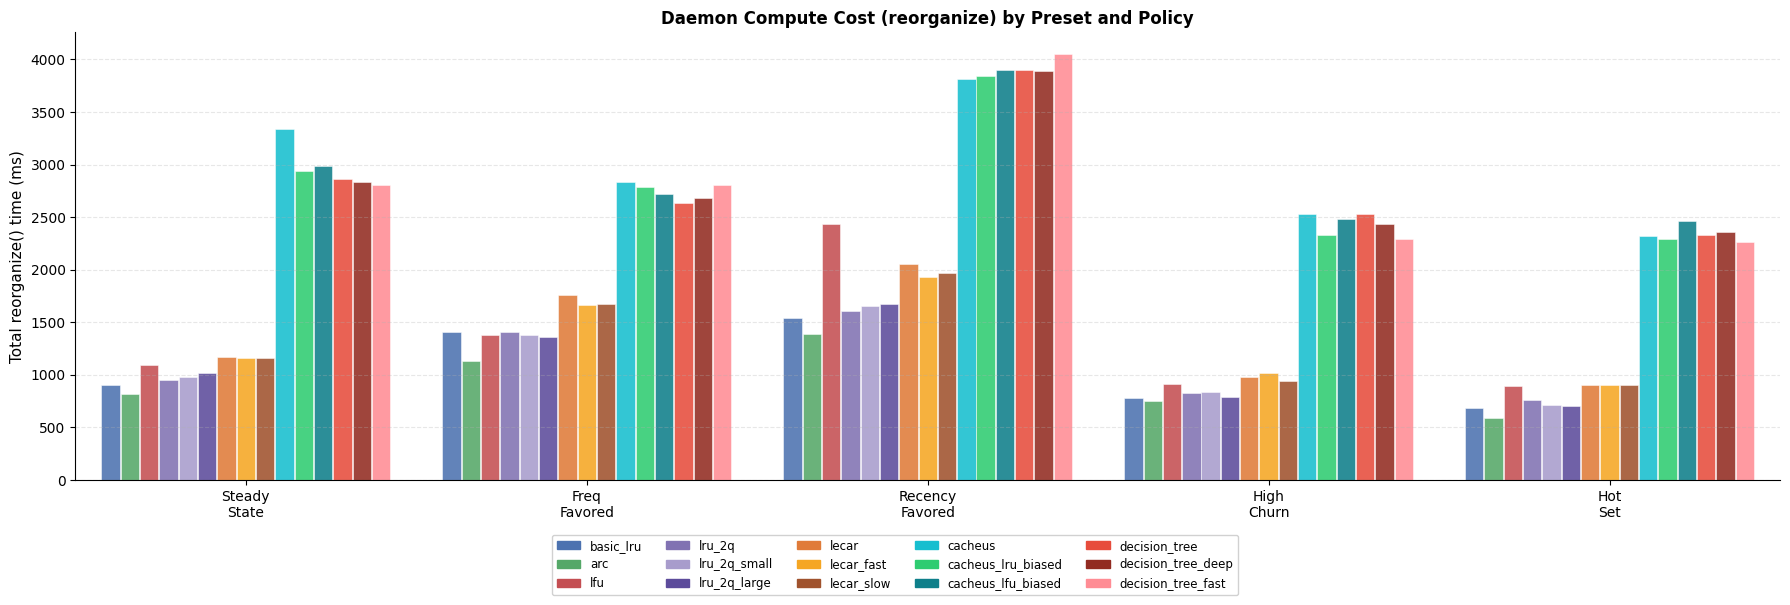

In [48]:
fig, ax = plt.subplots(figsize=(18, 6))
grouped_bar(ax, 'reorg_ms', 'Total reorganize() time (ms)',
            title='Daemon Compute Cost (reorganize) by Preset and Policy')
policy_legend(fig)
fig.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig('reorg_compute.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 6 — Hit Rate Heatmap (Preset × Policy)

Compact overview: each cell is hit rate %, greener = better.
Useful for spotting which policies consistently win or lose across all presets.

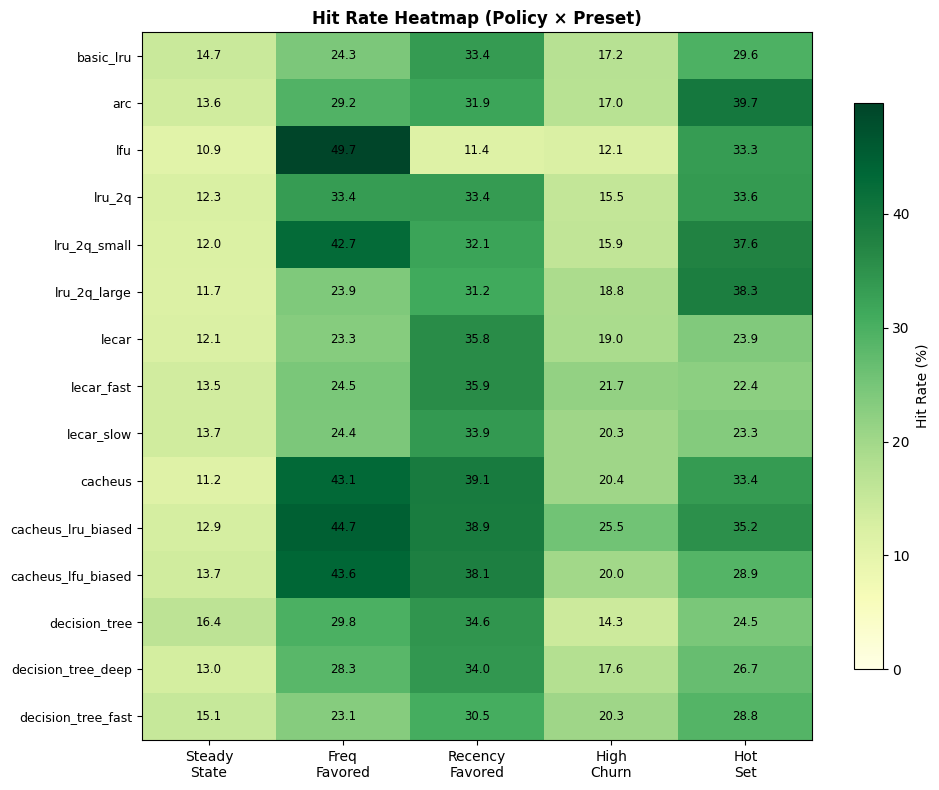

In [49]:
pivot = (
    df.groupby(['policy', 'preset'])['hit_pct'].mean()
      .unstack('preset')
      .reindex(index=POLICIES, columns=PRESETS)
)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlGn', vmin=0)

ax.set_xticks(range(len(PRESETS)))
ax.set_xticklabels([PRESET_LABELS[p] for p in PRESETS], fontsize=10)
ax.set_yticks(range(len(POLICIES)))
ax.set_yticklabels(POLICIES, fontsize=9)

for i, policy in enumerate(POLICIES):
    for j, preset in enumerate(PRESETS):
        val = pivot.loc[policy, preset]
        if not pd.isna(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    fontsize=8.5,
                    color='black' if val < 60 else 'white')

plt.colorbar(im, ax=ax, label='Hit Rate (%)', shrink=0.8)
ax.set_title('Hit Rate Heatmap (Policy × Preset)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('hit_rate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Table

In [19]:
summary = (
    df.groupby(['preset', 'policy'])
      .agg(
          hit_pct    =('hit_pct',    'mean'),
          promotions =('promotions', 'mean'),
          demotions  =('demotions',  'mean'),
          cold_KB    =('cold_KB',    'mean'),
          hot_KB     =('hot_KB',     'mean'),
          reorg_ms   =('reorg_ms',   'mean'),
      )
      .round(2)
)

pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
summary

hit_pct  promotions  demotions  cold_KB  \
preset            policy                                                        
frequency_favored arc                   29.25     5035.00    5337.00  2668.44   
                  basic_lru             24.30     5404.00    5714.00  2858.83   
                  cacheus               43.11     5363.00    5663.00  2834.66   
                  cacheus_lfu_biased    43.61     5327.00    5625.00  2809.63   
                  cacheus_lru_biased    44.70     5160.00    5471.00  2730.07   
                  decision_tree         29.82     5831.00    6114.00  3062.13   
                  decision_tree_deep    28.26     5790.00    6098.00  3069.03   
                  decision_tree_fast    23.14     5976.00    6274.00  3165.40   
                  lecar                 23.26     5434.00    5761.00  2897.68   
                  lecar_fast            24.51     5201.00    5485.00  2734.14   
                  lecar_slow            24.39     5244.00    5565.00  2791.21   
                  lfu                   49.74     4820.00    5101.00  2546.49   
                  lru_2q                33.42     5272.00    5624.00  2826.83   
                  lru_2q_large          23.93     5300.00    5592.00  2814.68   
                  lru_2q_small          42.68     5072.00    5351.00  2665.76   
high_churn        arc                   16.97     2155.00    3556.00  4037.06   
                  basic_lru             17.25     2019.00    3467.00  3895.54   
                  cacheus               20.39     2138.00    3553.00  4059.65   
                  cacheus_lfu_biased    19.97     2073.00    3523.00  3931.20   
                  cacheus_lru_biased    25.49     1946.00    3342.00  3760.88   
                  decision_tree         14.34     2175.00    3644.00  4028.06   
                  decision_tree_deep    17.64     2151.00    3535.00  4000.47   
                  decision_tree_fast    20.34     2032.00    3518.00  3970.96   
                  lecar                 18.97     2084.00    3536.00  3983.98   
                  lecar_fast            21.66     2097.00    3465.00  3953.27   
                  lecar_slow            20.30     1955.00    3418.00  3832.53   
                  lfu                   12.07     2250.00    3672.00  4133.78   
                  lru_2q                15.46     2189.00    3597.00  4029.81   
                  lru_2q_large          18.76     2118.00    3542.00  3969.31   
                  lru_2q_small          15.89     2194.00    3615.00  4063.43   
hot_set           arc                   39.72     2345.00    2792.00  3162.50   
                  basic_lru             29.65     2426.00    2908.00  3265.63   
                  cacheus               33.42     2718.00    3205.00  3561.69   
                  cacheus_lfu_biased    28.95     2922.00    3423.00  3829.20   
                  cacheus_lru_biased    35.23     2653.00    3113.00  3508.10   
                  decision_tree         24.49     2917.00    3390.00  3789.58   
                  decision_tree_deep    26.72     2823.00    3276.00  3691.24   
                  decision_tree_fast    28.81     2709.00    3179.00  3585.19   
                  lecar                 23.89     2600.00    3107.00  3480.51   
                  lecar_fast            22.43     2675.00    3176.00  3554.13   
                  lecar_slow            23.34     2580.00    3036.00  3395.79   
                  lfu                   33.28     2789.00    3295.00  3734.39   
                  lru_2q                33.65     2650.00    3113.00  3530.83   
                  lru_2q_large          38.28     2420.00    2868.00  3224.31   
                  lru_2q_small          37.58     2489.00    2948.00  3290.65   
recency_favored   arc                   31.95     5498.00    6266.00  1964.38   
                  basic_lru             33.42     5463.00    6265.00  1954.70   
                  cacheus               39.07     5611.00    6383.00 